In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from epymodelingsuite.multistrain.formatter import (
    compute_quantiles,
    add_state_abbreviations,
    compute_rate_trend_categories,
    compute_rate_trend_pmf,
    create_flusight_submission,
    RATE_TREND_CATEGORIES,
)
from epymodelingsuite.multistrain.aggregator import pull_single_strain_submission
from epymodelingsuite.schema.output import (
    get_flusight_quantiles,
    get_flusight_horizons,
    get_flusight_categorical_horizons,
)
from epymodelingsuite.utils.location import convert_location_name_format


## Configuration

Set timespan configs:

In [2]:
SUBMISSION_WEEK = "202617"
REFERENCE_DATE = "2026-05-02"
WINDOW = "202550-202616"

Choose augmentation and baseline:

In [3]:
AUGMENTED = True
BASELINE = True
BASELINE_k = 5

These configs are unlikely to need changing:

In [4]:
INCLUDE_SINGLE_STRAIN = True
DIST_FUNC = "wrmse"
STRAINS = "h1-h3-b"
TARGET = "hosp_aug" if AUGMENTED else "hosp"
TARGET_LONG = "flu_hosp_25"
SUFFIX = "_augmented" if AUGMENTED else ""

Derived config values:

In [5]:
REFERENCE_DT = pd.to_datetime(REFERENCE_DATE)
final_date = REFERENCE_DT + pd.Timedelta(weeks=4)
final_date

Timestamp('2026-05-30 00:00:00')

## Data

In [6]:
if INCLUDE_SINGLE_STRAIN:
    # Load single-strain submission file
    single_source_experiment = f"gs://gs_mobs_jessica/pipeline/flu/{SUBMISSION_WEEK}/{TARGET}_smc_{DIST_FUNC}_{WINDOW}"
    single_fname = f"output_hub_formatted.csv.gz"
    df_single = pull_single_strain_submission(source_location=single_source_experiment, fname=single_fname)
    df_single.head()

In [7]:
# Load ground truth hospital data
hospital_data = pd.read_csv(f"../flu-forecast-epydemix/common-data/surveillance/{TARGET_LONG}_{SUBMISSION_WEEK}_prelim{SUFFIX}.csv")
hospital_data['abbreviation'] = hospital_data['location_iso'].apply(lambda key: key.split("-")[-1])
hospital_data['date'] = pd.to_datetime(hospital_data['target_end_date'])

# Compute quantiles for both sampling methods
random_combined = pd.read_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/trajectories_aggregated.csv")
if BASELINE:
    baselines_avg = pd.read_csv("baselines_2025.csv")
    random_combined = random_combined.merge(baselines_avg, left_on = "location", right_on="epydemix_population")
    p_values = BASELINE_k / (BASELINE_k + random_combined['baseline'])
    random_combined['baseline_sample'] = np.random.negative_binomial(BASELINE_k, p_values)
    random_combined['target_total'] = random_combined['target_total'] + random_combined['baseline_sample']
random_quantiles = compute_quantiles(random_combined)

# Add abbreviations
random_quantiles = add_state_abbreviations(random_quantiles)
random_quantiles['date'] = pd.to_datetime(random_quantiles['date'])

# Get sorted list of populations (US first, then states alphabetically)
populations = sorted(random_quantiles['location'].unique())
populations = ['United_States'] + [p for p in populations if p != 'United_States']

print(f"Plotting {len(populations)} locations")

Plotting 52 locations


In [8]:
print(f"Quantiles shape: {random_quantiles.shape}")
print(f"Quantile columns: {[c for c in random_quantiles.columns if c.startswith('q')]}")
random_quantiles.head(10)

Quantiles shape: (1820, 26)
Quantile columns: ['q010', 'q025', 'q050', 'q100', 'q150', 'q200', 'q250', 'q300', 'q350', 'q400', 'q450', 'q500', 'q550', 'q600', 'q650', 'q700', 'q750', 'q800', 'q850', 'q900', 'q950', 'q975', 'q990']


,location,date,q010,q025,q050,q100,q150,q200,q250,q300,...,q650,q700,q750,q800,q850,q900,q950,q975,q990,abbreviation
0,United_States,2025-09-20,240.99,286.975,359.95,438.8,505.00,562.0,607.00,658.7,...,1057.00,1118.3,1191.00,1277.4,1420.45,1570.6,1841.25,2031.025,2292.05,US
1,United_States,2025-09-27,241.99,302.925,359.85,452.8,541.55,621.8,675.00,722.0,...,1173.35,1268.3,1371.25,1520.8,1742.30,2099.1,2769.10,3194.725,3684.01,US
2,United_States,2025-10-04,275.92,350.950,426.95,543.9,610.85,670.0,728.00,782.7,...,1391.70,1570.8,1828.25,2108.0,2412.45,2682.0,3187.10,3463.725,4209.19,US
3,United_States,2025-10-11,281.00,353.875,426.90,547.7,636.00,705.8,775.00,894.5,...,1850.45,2115.0,2338.75,2652.6,2938.20,3288.2,3878.75,4343.050,5181.48,US
4,United_States,2025-10-18,366.00,431.000,514.00,629.8,736.40,848.6,933.75,1077.6,...,2303.20,2516.3,2764.00,2987.2,3307.15,3722.9,4434.35,5051.325,6012.16,US
5,United_States,2025-10-25,286.86,411.975,543.90,698.3,869.40,994.0,1178.75,1361.5,...,2575.00,2799.0,3064.00,3292.6,3603.45,3915.1,4708.45,5183.125,6159.75,US
6,United_States,2025-11-01,390.88,531.750,670.70,876.5,1038.40,1282.2,1468.75,1656.5,...,2979.35,3173.8,3381.75,3683.4,3992.35,4389.2,5246.05,5933.075,6757.10,US
7,United_States,2025-11-08,409.69,525.850,773.90,1150.6,1474.80,1704.6,1977.00,2209.0,...,3636.35,3881.3,4073.75,4400.6,4715.15,5243.4,5963.30,6769.275,7428.04,US
8,United_States,2025-11-15,681.85,944.150,1189.90,1722.0,2058.60,2356.0,2663.25,2934.1,...,4492.20,4726.6,5043.50,5366.8,5794.15,6335.8,7223.90,8393.025,9165.22,US
9,United_States,2025-11-22,919.97,1370.975,1887.70,2425.1,2881.25,3264.2,3533.25,3807.4,...,5641.60,5957.9,6307.25,6766.0,7138.05,7708.5,8979.10,9757.750,10973.66,US


## Plot

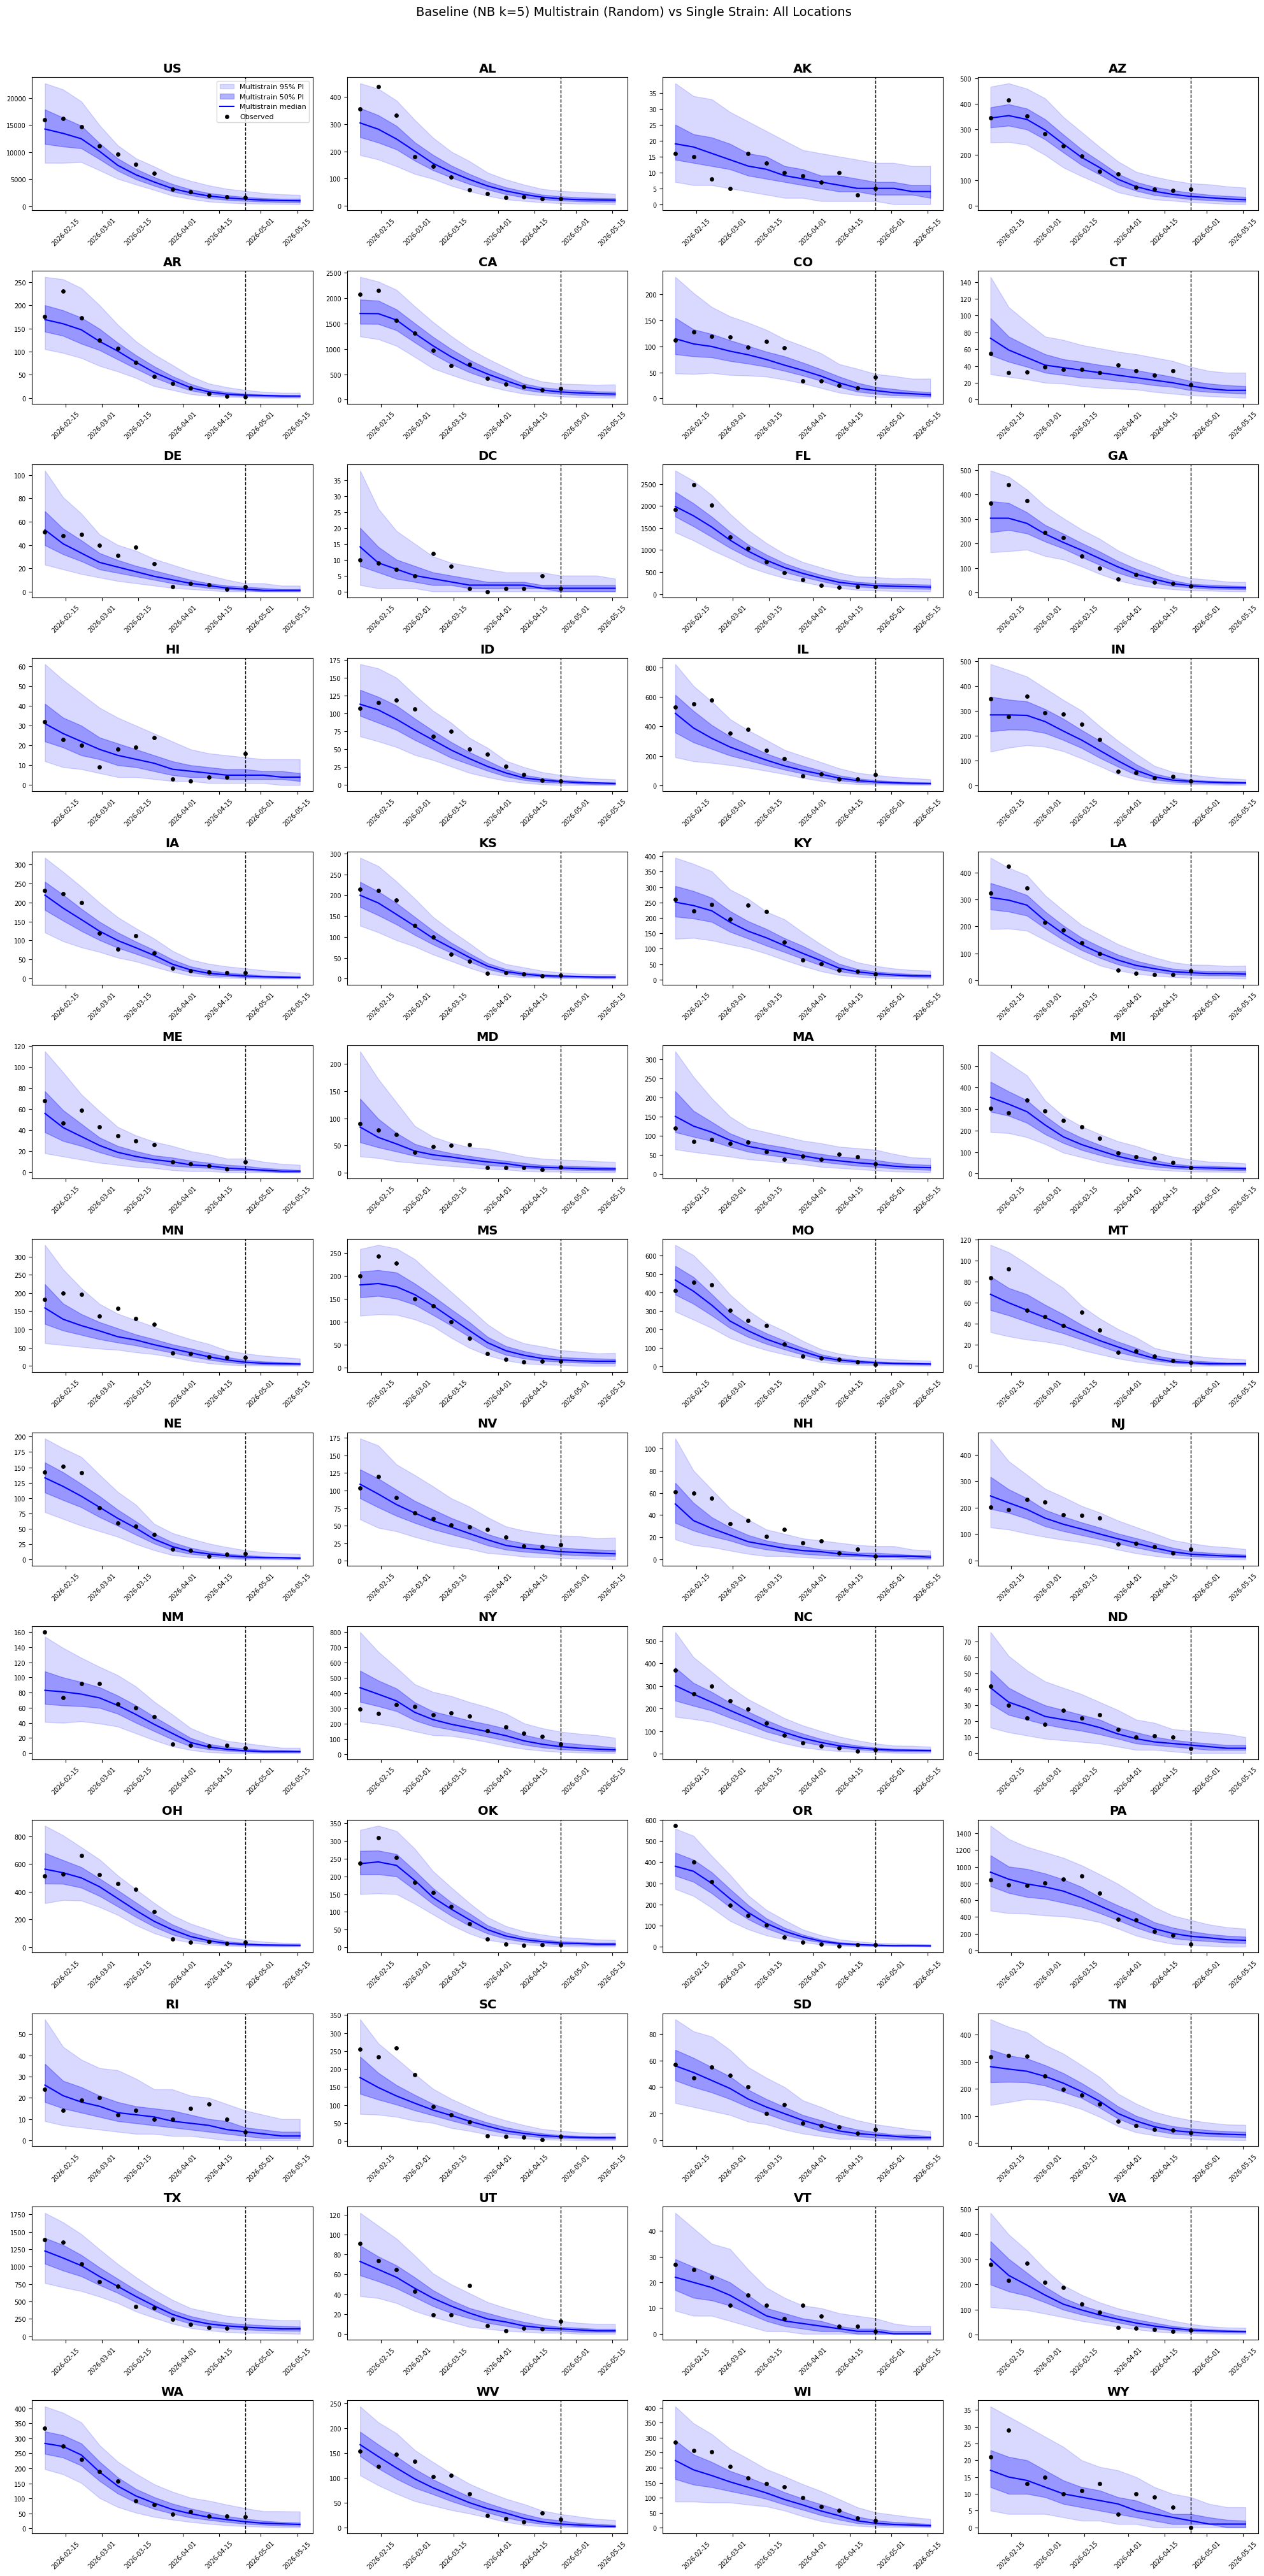

In [9]:
FILTER_PLOT = True
FILTER_PLOT_START = '2026-02-01'
LONG_PLOT_START = '2025-10-01'

if FILTER_PLOT:
    plot_start_date = pd.to_datetime(FILTER_PLOT_START)
    plot_prefix = 'filtered_'
    if BASELINE:
        plot_prefix = 'filtered_baseline_'
else:
    plot_start_date = pd.to_datetime(LONG_PLOT_START)
    plot_prefix = ''
    if BASELINE:
        plot_prefix = 'baseline_'

random_quantiles_filter =random_quantiles[(random_quantiles['date'] >= plot_start_date) & (random_quantiles['date'] < final_date)]

hospital_data_filter = hospital_data[(hospital_data['date'] >= plot_start_date) & (hospital_data['date'] < final_date)]

if INCLUDE_SINGLE_STRAIN:
    # Convert df_single to wide format for plotting (matching random_quantiles format)
    df_single_quantiles = df_single[df_single['output_type'] == 'quantile'].copy()
    df_single_quantiles['target_end_date'] = pd.to_datetime(df_single_quantiles['target_end_date'])
    
    # Pivot to get quantile columns
    df_single_wide = df_single_quantiles.pivot_table(
        index=['location', 'target_end_date'],
        columns='output_type_id',
        values='value'
    ).reset_index()
    
    # Rename columns to match random_quantiles format
    df_single_wide.columns.name = None
    df_single_wide = df_single_wide.rename(columns={
        'target_end_date': 'date',
        '0.025': 'q025', '0.25': 'q250', '0.5': 'q500', '0.75': 'q750', '0.975': 'q975'
    })
    
    # Filter to date range
    df_single_filter = df_single_wide[
        (df_single_wide['date'] >= plot_start_date) & 
        (df_single_wide['date'] < final_date)
    ]

# Create 13x4 comparison figure: Random multistrain vs Single strain
fig, axes = plt.subplots(13, 4, figsize=(20, 40))
axes = axes.flatten()

for idx, pop in enumerate(populations):
    ax = axes[idx]
    abbrev = convert_location_name_format(value=pop, output_format="abbreviation", input_format="epydemix_population", location_type="iso")
    location_code = convert_location_name_format(value=abbrev, output_format="FIPS", input_format="abbreviation", location_type="iso")
    
    # Get data for this population
    rand_pop = random_quantiles_filter[random_quantiles_filter['location'] == pop].sort_values('date')
    hosp_pop = hospital_data_filter[hospital_data_filter['abbreviation'] == abbrev].sort_values('date')
    if INCLUDE_SINGLE_STRAIN:
        single_pop = df_single_filter[df_single_filter['location'] == location_code].sort_values('date')
    
    # Plot random multistrain sampling (blue)
    ax.fill_between(rand_pop['date'], rand_pop['q025'], rand_pop['q975'], 
                    alpha=0.15, color='blue', label='Multistrain 95% PI')
    ax.fill_between(rand_pop['date'], rand_pop['q250'], rand_pop['q750'], 
                    alpha=0.3, color='blue', label='Multistrain 50% PI')
    ax.plot(rand_pop['date'], rand_pop['q500'], 'b-', linewidth=1.5, label='Multistrain median')
    
    # Plot single strain (green)
    if INCLUDE_SINGLE_STRAIN:
        ax.fill_between(single_pop['date'], single_pop['q025'], single_pop['q975'], 
                        alpha=0.15, color='green', label='Single strain 95% PI')
        ax.fill_between(single_pop['date'], single_pop['q250'], single_pop['q750'], 
                        alpha=0.3, color='green', label='Single strain 50% PI')
        ax.plot(single_pop['date'], single_pop['q500'], 'g-', linewidth=1.5, label='Single strain median')
    
    # Plot ground truth (black markers)
    ax.scatter(hosp_pop['date'], hosp_pop['hospitalizations'], 
               color='black', s=15, zorder=5, label='Observed')
    
    ax.set_title(abbrev, fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.axvline(REFERENCE_DT - pd.Timedelta(weeks=1), color='black', linestyle='--', linewidth=1)
    
    # Only show legend for first subplot
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide any unused subplots
for idx in range(len(populations), len(axes)):
    axes[idx].set_visible(False)
    

if BASELINE:
    title = f'Baseline (NB k={BASELINE_k}) Multistrain (Random) vs Single Strain: All Locations'
else:
    title = 'Multistrain (Random) vs Single Strain: All Locations'
plt.suptitle(title, fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{plot_prefix}multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}_multistrain_vs_single_comparison.pdf', 
            dpi=150, bbox_inches='tight')
plt.show()

## Submission File

In [10]:
# Compute rate trend categories for each trajectory
# Baseline comes from surveillance data, target from trajectories
categories_df = compute_rate_trend_categories(
    df=random_combined,
    reference_date=REFERENCE_DATE,
    surveillance_df=hospital_data,
    horizons=get_flusight_categorical_horizons(),
    value_col='target_total',
    surveillance_date_col='date',
    surveillance_value_col='hospitalizations',
    surveillance_location_col='abbreviation'
)

print(f"Categories computed: {len(categories_df):,} rows")
print(f"Unique populations: {categories_df['population'].nunique()}")
print(f"Horizons: {sorted(categories_df['horizon'].unique())}")
print(f"\nCategory distribution:")
print(categories_df['category'].value_counts())
print(f"\nBaseline values come from surveillance (same for all samples per location):")
categories_df.tail(10)



Categories computed: 156,000 rows
Unique populations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2)]

Category distribution:
category
stable            139291
decrease           13516
increase            3136
large_increase        57
Name: count, dtype: int64

Baseline values come from surveillance (same for all samples per location):


,reference_date,sample_id,population,abbreviation,baseline_date,horizon,target_date,baseline_value,target_value,count_change,rate_change,category
155990,2026-05-02,240,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,4.0,4.0,0.680714,stable
155991,2026-05-02,221,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,4.0,4.0,0.680714,stable
155992,2026-05-02,961,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,1.0,1.0,0.170179,stable
155993,2026-05-02,339,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,0.0,0.0,0.000000,stable
155994,2026-05-02,419,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,0.0,0.0,0.000000,stable
155995,2026-05-02,847,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,3.0,3.0,0.510536,stable
155996,2026-05-02,179,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,1.0,1.0,0.170179,stable
155997,2026-05-02,465,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,4.0,4.0,0.680714,stable
155998,2026-05-02,516,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,4.0,4.0,0.680714,stable
155999,2026-05-02,529,United_States_Wyoming,WY,2026-04-25,2,2026-05-16,0.0,1.0,1.0,0.170179,stable


In [11]:
# Compute PMF from categories
pmf_df = compute_rate_trend_pmf(categories_df)

print(f"PMF shape: {pmf_df.shape}")
print(f"Columns: {pmf_df.columns.tolist()}")
print(f"\nProbabilities sum to 1: {(pmf_df[RATE_TREND_CATEGORIES].sum(axis=1).round(6) == 1).all()}")
#pmf_df.head(20)

PMF shape: (156, 9)
Columns: ['population', 'abbreviation', 'horizon', 'target_date', 'large_decrease', 'decrease', 'stable', 'increase', 'large_increase']

Probabilities sum to 1: True


In [12]:
# Format PMF for hub submission (long format)
pmf_long = pmf_df.melt(
    id_vars=['population', 'abbreviation', 'horizon', 'target_date'],
    value_vars=RATE_TREND_CATEGORIES,
    var_name='output_type_id',
    value_name='value'
)

# Add required columns for FluSight format
pmf_long['target'] = 'wk flu hosp rate change'
pmf_long['output_type'] = 'pmf'
pmf_long['location'] = pmf_long['abbreviation']

# Reorder columns
hub_pmf = pmf_long[[
    'location', 'target', 'horizon', 'target_date', 
    'output_type', 'output_type_id', 'value'
]]

print(f"Hub submission format shape: {hub_pmf.shape}")
print(f"\nSample rows:")
hub_pmf.head(15)

Hub submission format shape: (780, 7)

Sample rows:


,location,target,horizon,target_date,output_type,output_type_id,value
0,US,wk flu hosp rate change,0,2026-05-02,pmf,large_decrease,0.0
1,US,wk flu hosp rate change,1,2026-05-09,pmf,large_decrease,0.0
2,US,wk flu hosp rate change,2,2026-05-16,pmf,large_decrease,0.0
3,AL,wk flu hosp rate change,0,2026-05-02,pmf,large_decrease,0.0
4,AL,wk flu hosp rate change,1,2026-05-09,pmf,large_decrease,0.0
5,AL,wk flu hosp rate change,2,2026-05-16,pmf,large_decrease,0.0
6,AK,wk flu hosp rate change,0,2026-05-02,pmf,large_decrease,0.0
7,AK,wk flu hosp rate change,1,2026-05-09,pmf,large_decrease,0.0
8,AK,wk flu hosp rate change,2,2026-05-16,pmf,large_decrease,0.0
9,AZ,wk flu hosp rate change,0,2026-05-02,pmf,large_decrease,0.0


In [13]:
# Export PMF for hub submission (uncomment to save)
# output_file = f"../data/multistrain-data/{SUBMISSION_WEEK}/rate_trend_pmf.csv"
# hub_pmf.to_csv(output_file, index=False)
# print(f"Saved PMF to: {output_file}")

# Verify probabilities sum to 1 for each location/horizon
verification = hub_pmf.groupby(['location', 'horizon'])['value'].sum()
print("All PMFs sum to 1:", (verification.round(6) == 1).all())
print(f"\nTotal PMF entries: {len(hub_pmf)}")
print(f"Locations: {hub_pmf['location'].nunique()}")
print(f"Horizons: {sorted(hub_pmf['horizon'].unique())}")
print(f"Categories per location/horizon: {len(RATE_TREND_CATEGORIES)}")

All PMFs sum to 1: True

Total PMF entries: 780
Locations: 52
Horizons: [np.int64(0), np.int64(1), np.int64(2)]
Categories per location/horizon: 5


In [14]:
# Create complete FluSight submission
submission = create_flusight_submission(
    trajectories_df=random_combined,
    pmf_df=pmf_df,
    reference_date=REFERENCE_DATE,
    horizons=get_flusight_horizons(),
    value_col='target_total'
)

print(f"Submission shape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nTargets: {submission['target'].unique()}")
print(f"Output types: {submission['output_type'].unique()}")
print(f"Horizons: {sorted(submission['horizon'].unique())}")
print(f"Locations: {submission['location'].nunique()}")
print(f"\nRows per target:")
print(submission.groupby(['target', 'output_type']).size())

Submission shape: (5564, 8)

Columns: ['reference_date', 'horizon', 'target_end_date', 'location', 'target', 'output_type', 'output_type_id', 'value']

Targets: <StringArray>
['wk flu hosp rate change', 'wk inc flu hosp']
Length: 2, dtype: str
Output types: <StringArray>
['pmf', 'quantile']
Length: 2, dtype: str
Horizons: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Locations: 52

Rows per target:
target                   output_type
wk flu hosp rate change  pmf             780
wk inc flu hosp          quantile       4784
dtype: int64


In [15]:
submission

,reference_date,horizon,target_end_date,location,target,output_type,output_type_id,value
0,2026-05-02,0,2026-05-02,01,wk flu hosp rate change,pmf,decrease,0.065
1,2026-05-02,0,2026-05-02,01,wk flu hosp rate change,pmf,increase,0.084
2,2026-05-02,0,2026-05-02,01,wk flu hosp rate change,pmf,large_decrease,0.000
3,2026-05-02,0,2026-05-02,01,wk flu hosp rate change,pmf,large_increase,0.000
4,2026-05-02,0,2026-05-02,01,wk flu hosp rate change,pmf,stable,0.851
...,...,...,...,...,...,...,...,...
5559,2026-05-02,2,2026-05-16,US,wk inc flu hosp,quantile,0.85,1570.000
5560,2026-05-02,2,2026-05-16,US,wk inc flu hosp,quantile,0.9,1702.000
5561,2026-05-02,2,2026-05-16,US,wk inc flu hosp,quantile,0.95,1907.000
5562,2026-05-02,2,2026-05-16,US,wk inc flu hosp,quantile,0.975,2086.000


In [16]:
sub_prefix = "baseline_" if BASELINE else ""
submission.to_csv(f"../experiments/multistrain/{SUBMISSION_WEEK}-{TARGET}/multi_{TARGET}_smc_{DIST_FUNC}_{WINDOW}_{STRAINS}/{sub_prefix}{REFERENCE_DATE}-MOBS-EpyStrain_Flu.csv",
                  index=False)